# Clasificadores Probabilísticos Gaussianos: NB, LDA y QDA
## Unidad 2 · Clase 3 · Duración: 2 horas

**versión: 2025-1  |  modificado: 2026-04-06**

---

### 🗺️ Mapa de la clase

| Sección | Tema | Tiempo estimado |
|---------|------|-----------------|
| 1 | El marco generativo: P(X\|Y) y Bayes | 20 min |
| 2 | Naive Bayes Gaussiano: independencia condicional | 25 min |
| 3 | LDA: covarianza compartida, frontera lineal | 25 min |
| 4 | QDA: covarianza por clase, frontera cuadrática | 15 min |
| 5 | Experimento comparativo: visualización de fronteras | 20 min |
| 6 | Ejercicio en clase | 15 min |

---

### 📋 Prerequisitos

| Pregrado | Doctorado |
|----------|-----------|
| Probabilidad condicional, regla de Bayes | Lo anterior + distribución gaussiana multivariada |
| Regresión Logística (Clase U2-C1) | Estimación de máxima verosimilitud (MLE) |
| Métricas de clasificación (Clase U2-C1) | Álgebra lineal: determinante, inversa de matrices |

---

---
<div style="background-color:#F8F9FA; border:2px solid #AEB6BF;
     padding:12px 18px; border-radius:8px; margin:10px 0;">
<strong>🎓 Modo de uso:</strong> Este notebook es compartido por dos cursos.<br><br>
<span style="color:#2E86C1; font-weight:bold;">🔵 Pregrado</span>
— Trabaja el contenido general y los bloques azules. Los bloques amarillos
son opcionales y te darán contexto adicional.<br><br>
<span style="color:#B7950B; font-weight:bold;">🟡 Doctorado</span>
— Trabaja el contenido general y <em>ambos</em> bloques. Los bloques azules
te ofrecen la intuición; los amarillos, la formalización.
</div>

---

In [ ]:
#pip install numpy pandas matplotlib seaborn scikit-learn 

  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB

In [6]:
# ── SETUP — NO MODIFICAR ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# dataset: iris (sklearn built-in)  |  generado sintéticamente: no
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name='especie')

# dataset: wine (sklearn built-in)  |  generado sintéticamente: no
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name='variedad')

# Splits estratificados
X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=RANDOM_STATE, stratify=y_iris
)

# Para visualización: solo las 2 primeras features de Iris (pueden graficarse en 2D)
FEAT_VIZ = list(iris.feature_names[:2])   # sepal length, sepal width
X_viz = X_iris[FEAT_VIZ].values

print('✅ Setup completo')
print(f'   numpy {np.__version__} · pandas {pd.__version__} · scikit-learn {sklearn_version}')
print(f'   Iris  — {X_iris.shape[0]} muestras · {X_iris.shape[1]} features · 3 clases')
print(f'   Wine  — {X_wine.shape[0]} muestras · {X_wine.shape[1]} features · 3 clases')

✅ Setup completo
   numpy 2.4.4 · pandas 3.0.2 · scikit-learn 1.8.0
   Iris  — 150 muestras · 4 features · 3 clases
   Wine  — 178 muestras · 13 features · 3 clases


---
## Sección 1 — El Marco Generativo y el Teorema de Bayes

### 1.1 Historia del teorema

El resultado que usamos en esta clase fue publicado póstumamente en 1763 por Richard Price, quien editó los papeles del reverendo Thomas Bayes tras su muerte. En esa época no existía el concepto de probabilidad condicional tal como lo conocemos hoy: Bayes buscaba resolver el problema de la **inferencia inversa**, es decir, cómo actualizar creencias a la luz de evidencia nueva.

Fue Pierre-Simon Laplace quien, de forma independiente y con mayor generalidad, formalizó el teorema en 1774 y lo convirtió en una herramienta práctica de inferencia estadística. Durante casi dos siglos el enfoque bayesiano fue considerado controversial frente a la estadística frecuentista. Solo en las últimas décadas, con el aumento del poder computacional, el razonamiento bayesiano se volvió omnipresente en machine learning.

---

### 1.2 Derivación del teorema de Bayes

El punto de partida es la **definición de probabilidad condicional**. Para dos eventos $A$ y $B$ con $P(B) > 0$:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

Esta expresión dice: la probabilidad de $A$ dado que $B$ ocurrió es la fracción del "mundo donde $B$ ocurre" que también tiene a $A$.

De forma simétrica:

$$P(B \mid A) = \frac{P(A \cap B)}{P(A)}$$

Las dos expresiones comparten el mismo numerador $P(A \cap B)$. Despejamos ese numerador de la segunda ecuación:

$$P(A \cap B) = P(B \mid A) \cdot P(A)$$

Y lo sustituimos en la primera:

$$\boxed{P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}}$$

Eso es el **teorema de Bayes**. Tiene cuatro componentes con nombres canónicos:

| Término | Notación | Significado |
|---------|----------|-------------|
| **Posterior** | $P(A \mid B)$ | Lo que queremos saber: probabilidad de $A$ *después* de ver $B$ |
| **Verosimilitud** | $P(B \mid A)$ | Qué tan probable es observar $B$ si $A$ es cierto |
| **Prior** | $P(A)$ | Creencia inicial sobre $A$ antes de ver $B$ |
| **Evidencia** | $P(B)$ | Probabilidad marginal de observar $B$ (normalización) |

---

### 1.3 Aplicación a clasificación

Hasta ahora hemos visto clasificadores **discriminativos**: modelan directamente $P(Y \mid X)$. Los modelos de esta clase son **generativos**: modelan $P(X \mid Y=k)$ y aplican el teorema de Bayes para obtener la clase más probable:

$$P(Y=k \mid X=x) = \frac{\overbrace{P(X=x \mid Y=k)}^{\text{verosimilitud}} \cdot \overbrace{P(Y=k)}^{\text{prior}}}{\underbrace{P(X=x)}_{\text{evidencia (constante)}}}$$

Como $P(X=x)$ es **idéntica para todas las clases** $k$ (no depende de $k$), podemos ignorarla en la comparación. La regla de decisión queda:

$$\hat{y} = \arg\max_k \; P(X=x \mid Y=k) \cdot P(Y=k)$$

La diferencia entre NB, LDA y QDA está en **cómo modelan** $P(X \mid Y=k)$.


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>

**Analogía:** Imagina que quieres identificar si un animal es un gato, un perro o un conejo a partir de su peso y altura. Un modelo generativo piensa así: "los gatos pesan X kg con tal variación, los perros pesan Y kg, los conejos Z kg". Aprende a describir cada clase y luego, dado un animal nuevo, pregunta: ¿a cuál descripción se parece más?

Un modelo discriminativo, en cambio, aprende directamente las fronteras: "si el animal pesa más de 10 kg, probablemente sea perro". No sabe cómo es un gato típico, solo sabe dónde están los límites.

> 🤔 **Pregunta:** ¿Cuál modelo te permitiría **generar** muestras sintéticas de cada clase? ¿El generativo o el discriminativo?

> 🤔 **Pregunta:** Si tienes muy pocos datos de entrenamiento, ¿cuál de los dos enfoques crees que sería más robusto? ¿Por qué?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la formalización? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>

**Derivación formal via ley de probabilidad total:**

El denominador $P(X=x)$ se expande usando la **ley de probabilidad total** sobre las $K$ clases:

$$P(X=x) = \sum_{k=1}^K P(X=x \mid Y=k) \cdot P(Y=k)$$

Lo que convierte el teorema de Bayes en su forma completa para clasificación:

$$P(Y=k \mid X=x) = \frac{P(X=x \mid Y=k) \cdot P(Y=k)}{\displaystyle\sum_{j=1}^K P(X=x \mid Y=j) \cdot P(Y=j)}$$

Esta forma es la que realmente computa sklearn internamente en `predict_proba`.

**Estimación MLE del prior:**

El estimador de máxima verosimilitud del prior es simplemente la frecuencia relativa:

$$\hat{\pi}_k = \hat{P}(Y=k) = \frac{n_k}{n}$$

donde $n_k$ es el número de muestras de la clase $k$ y $n$ es el total. Es el estimador no sesgado de mínima varianza bajo el supuesto de que las clases son intercambiables.

**El clasificador de Bayes óptimo:**

Si conociéramos las verdaderas distribuciones $P(X \mid Y=k)$, el clasificador de Bayes **minimiza el error de clasificación esperado** (riesgo de Bayes). Formalmente, minimiza:

$$R(h) = E_{X,Y}[\mathbf{1}[h(X) \neq Y]] = P(h(X) \neq Y)$$

El clasificador óptimo es $h^*(x) = \arg\max_k P(Y=k \mid X=x)$, que es exactamente la regla MAP (Maximum A Posteriori). Su tasa de error, el **error de Bayes**, es el mínimo teórico alcanzable para cualquier clasificador dado ese problema y esas distribuciones.

**Tradeoff bias-varianza en modelos generativos:**

En la práctica no conocemos $P(X \mid Y=k)$ y la estimamos de datos finitos. Los supuestos del modelo (p.ej., gaussiana con covarianza diagonal) actúan como **regularización implícita**: reducen la varianza de estimación a costa de introducir sesgo si los supuestos son incorrectos.

> 📄 **Ref:** Ng & Jordan (2002). *On Discriminative vs. Generative Classifiers*. NIPS 2002.

> 🔬 **Para investigar:** Ng & Jordan demuestran que LR converge más lento que NB pero a mejor error asintótico. ¿Cuál es el $n^*$ de cruce y de qué depende?

<br>
<span style="font-size:0.85em; color:#7D6608;">→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.</span>
</div>


---
## Sección 2 — Naive Bayes Gaussiano

### 2.1 La matriz de covarianza: qué es y por qué importa

Antes de describir NB, necesitamos entender el objeto matemático central de esta clase: la **matriz de covarianza**.

La covarianza entre dos features $X_i$ y $X_j$ mide cómo varían juntas:

$$\text{Cov}(X_i, X_j) = E[(X_i - \mu_i)(X_j - \mu_j)]$$

Si es positiva, cuando $X_i$ sube, $X_j$ también tiende a subir. Si es negativa, se mueven en direcciones opuestas. Si es cero, son linealmente independientes.

La **matriz de covarianza** $\Sigma \in \mathbb{R}^{d \times d}$ organiza todas las covarianzas entre pares de features:

$$\Sigma = \begin{pmatrix} \text{Var}(X_1) & \text{Cov}(X_1,X_2) & \cdots & \text{Cov}(X_1,X_d) \\ \text{Cov}(X_2,X_1) & \text{Var}(X_2) & \cdots & \text{Cov}(X_2,X_d) \\ \vdots & & \ddots & \vdots \\ \text{Cov}(X_d,X_1) & \cdots & & \text{Var}(X_d) \end{pmatrix}$$

La diagonal contiene las **varianzas** de cada feature. Los elementos fuera de la diagonal son las **covarianzas cruzadas**. La matriz es siempre simétrica ($\Sigma = \Sigma^T$) y semidefinida positiva ($v^T \Sigma v \geq 0$ para todo $v$).

**¿Por qué es compleja de estimar?**

Para $d$ features, $\Sigma$ tiene $d(d+1)/2$ entradas únicas. Con $d = 100$, son 5.050 parámetros solo para la covarianza. Cada uno requiere datos para ser estimado de forma estable. La regla empírica es contar con al menos $5d$ a $10d$ muestras por clase, lo que con $d = 100$ implica 500–1.000 muestras **por clase**. En muchos problemas reales eso no está disponible, y la matriz estimada puede ser **singular** (no invertible), lo que rompe el clasificador.

Esta complejidad es precisamente lo que motiva los distintos supuestos de NB, LDA y QDA.

---

### 2.2 El supuesto de Naive Bayes

NB asume que **todas las features son condicionalmente independientes** dada la clase. Esto equivale a asumir que $\Sigma_k$ es **diagonal**: todas las covarianzas cruzadas son cero.

$$P(X=x \mid Y=k) = \prod_{j=1}^{d} P(X_j=x_j \mid Y=k)$$

Asumiendo además que cada feature sigue una **distribución gaussiana** dentro de cada clase:

$$P(X_j = x_j \mid Y=k) = \frac{1}{\sqrt{2\pi\sigma_{kj}^2}} \exp\!\left(-\frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2}\right)$$

Los parámetros $\mu_{kj}$ y $\sigma_{kj}^2$ se estiman como la media y varianza muestral de la feature $j$ dentro de la clase $k$. Solo hay $2Kd$ parámetros en total — una reducción dramática respecto a estimar $\Sigma_k$ completa.


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>

**Analogía:** NB trata cada feature como si fuera **independiente** de las demás. Si clasificas correos como spam mirando las palabras "oferta" y "gratis", NB asume que la probabilidad de que aparezca "gratis" no cambia si ya apareció "oferta". En la realidad, esas palabras sí co-ocurren. Pero sorprendentemente, el modelo funciona igual.

> 🤔 **Pregunta:** Si las features tuvieran correlación perfecta ($\rho = 1$), ¿qué problema podría tener NB al estimar la probabilidad de la clase?

> 🤔 **Pregunta:** ¿Cuántos parámetros necesita estimar Gaussian NB para un problema con $d$ features y $K$ clases? ¿Cómo cambia eso respecto a un modelo que sí considera covarianzas?

**Fortaleza clave:** Por asumir independencia, NB necesita estimar $2 \cdot K \cdot d$ parámetros (media y varianza por feature y clase). Con pocas muestras, eso es una enorme ventaja.

<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la derivación formal? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>

**Derivación paso a paso del log-likelihood de Gaussian NB:**

Partimos de la regla de decisión MAP:

$$\hat{y} = \arg\max_k P(Y=k \mid x)$$

**Paso 1 — Aplicar Bayes e ignorar la evidencia:**

$$\hat{y} = \arg\max_k P(X=x \mid Y=k) \cdot P(Y=k)$$

**Paso 2 — Sustituir el supuesto de independencia condicional:**

$$P(X=x \mid Y=k) = \prod_{j=1}^d P(X_j = x_j \mid Y=k)$$

**Paso 3 — Sustituir la densidad gaussiana univariada:**

$$\prod_{j=1}^d P(X_j = x_j \mid Y=k) = \prod_{j=1}^d \frac{1}{\sqrt{2\pi\sigma_{kj}^2}} \exp\!\left(-\frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2}\right)$$

**Paso 4 — Tomar logaritmo** (el $\arg\max$ no cambia porque $\log$ es monótona creciente):

$$\log \left[\prod_{j=1}^d \frac{1}{\sqrt{2\pi\sigma_{kj}^2}} \exp\!\left(-\frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2}\right) \cdot \pi_k\right]$$

**Paso 5 — Separar el producto en suma de logaritmos:**

$$= \log \pi_k + \sum_{j=1}^d \left[ \log \frac{1}{\sqrt{2\pi\sigma_{kj}^2}} - \frac{(x_j - \mu_{kj})^2}{2\sigma_{kj}^2} \right]$$

**Paso 6 — Simplificar** usando $\log \frac{1}{\sqrt{2\pi\sigma^2}} = -\frac{1}{2}\log(2\pi) - \frac{1}{2}\log\sigma^2$:

$$= \log \pi_k - \frac{d}{2}\log(2\pi) - \frac{1}{2}\sum_{j=1}^d \log \sigma_{kj}^2 - \frac{1}{2}\sum_{j=1}^d \frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2}$$

El término $-\frac{d}{2}\log(2\pi)$ es **constante para todas las clases** → cancela en el $\arg\max$. La **función discriminante de Gaussian NB** queda:

$$\boxed{\delta_k^{NB}(x) = \log \pi_k - \frac{1}{2}\sum_{j=1}^d \log \sigma_{kj}^2 - \frac{1}{2}\sum_{j=1}^d \frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2}}$$

**Geometría de la frontera:** La frontera entre clases $k$ y $l$ satisface $\delta_k^{NB}(x) = \delta_l^{NB}(x)$. El último término es cuadrático en $x$ pero **sin términos cruzados** $x_i x_j$ (porque la suma es sobre $j$ independientemente). Si además $\sigma_{kj}^2 = \sigma_{lj}^2$ para todo $j$, el término cuadrático cancela y la frontera es **lineal**.

**NB como QDA con $\Sigma_k$ diagonal:**

$$\Sigma_k^{NB} = \text{diag}(\sigma_{k1}^2, \ldots, \sigma_{kd}^2)$$

Es exactamente QDA con la restricción de que todas las covarianzas cruzadas son cero.

> 📄 **Ref:** Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press. Cap. 4.2.

> 🔬 **Para investigar:** Si se fuerza $\sigma_{kj}^2 = \sigma_j^2$ (varianza igual entre clases, distinta entre features), ¿qué forma toma la frontera y a cuál de los tres modelos se asemeja más?

<br>
<span style="font-size:0.85em; color:#7D6608;">→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.</span>
</div>


In [7]:
# ━━━ SECCIÓN 2: NAIVE BAYES GAUSSIANO ━━━

# Entrenamiento
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)
y_pred_gnb = gnb.predict(X_te)

# Parámetros aprendidos: media y varianza por clase y feature
print('=== Parámetros aprendidos por Gaussian NB ===')
param_df = pd.DataFrame()
for k, clase in enumerate(iris.target_names):
    row = {'clase': clase}
    for j, feat in enumerate(iris.feature_names):
        row[f'μ_{feat[:6]}'] = round(gnb.theta_[k, j], 2)
        row[f'σ²_{feat[:6]}'] = round(gnb.var_[k, j], 3)
    param_df = pd.concat([param_df, pd.DataFrame([row])], ignore_index=True)

param_df = param_df.set_index('clase')
print(param_df.to_string())
print(f'\nTotal parámetros (media+var) = {2 * len(iris.target_names) * len(iris.feature_names)}')
print(f'Accuracy en test: {accuracy_score(y_te, y_pred_gnb):.3f}')

=== Parámetros aprendidos por Gaussian NB ===
            μ_sepal   σ²_sepal   μ_petal   σ²_petal 
clase                                               
setosa          3.41      0.155      0.25      0.013
versicolor      2.75      0.093      1.32      0.034
virginica       2.98      0.122      2.04      0.070

Total parámetros (media+var) = 24
Accuracy en test: 0.967


In [8]:
# [PhD]
# ━━━ NB DESDE CERO: verificar que coincide con sklearn ━━━
import scipy.stats as stats

def gnb_predict_scratch(X, classes, theta, var, priors):
    """Implementación manual de Gaussian NB para verificar sklearn."""
    log_probs = []
    for k in range(len(classes)):
        # Log-prior
        log_prior = np.log(priors[k])
        # Log-verosimilitud: suma de log-gaussianas por feature
        log_likelihood = np.sum(
            stats.norm.logpdf(X, loc=theta[k], scale=np.sqrt(var[k])),
            axis=1
        )
        log_probs.append(log_prior + log_likelihood)
    return np.array(log_probs).T.argmax(axis=1)

y_scratch = gnb_predict_scratch(
    X_te.values, iris.target_names,
    gnb.theta_, gnb.var_, gnb.class_prior_
)
match = np.mean(y_scratch == y_pred_gnb)
print(f'[PhD] Implementación desde cero vs sklearn: {match*100:.1f}% coincidencia')
assert match == 1.0, 'Las implementaciones difieren — revisar derivación'

[PhD] Implementación desde cero vs sklearn: 100.0% coincidencia


---
## Sección 3 — LDA: Análisis de Discriminante Lineal

### 3.1 La covarianza compartida: qué implica y por qué simplifica

LDA también asume distribución gaussiana por clase, pero relaja el supuesto de independencia de NB: **permite correlaciones entre features**. Lo hace modelando la distribución de cada clase con una gaussiana multivariada de **covarianza completa**.

Sin embargo, hace un supuesto diferente: que **todas las clases comparten la misma matriz de covarianza** $\Sigma$:

$$P(X = x \mid Y = k) = \mathcal{N}(x \mid \mu_k, \Sigma)$$

La idea geométrica es que todas las clases tienen la **misma forma** de nube de puntos — misma orientación, mismos ejes, mismo tamaño — pero distintos **centros** $\mu_k$.

$\Sigma$ se estima **pooling** los datos de todas las clases: se calcula la desviación de cada punto respecto al centroide de su propia clase, y se promedia sobre todo el dataset:

$$\hat{\Sigma} = \frac{1}{n - K} \sum_{k=1}^K \sum_{i:\, y_i=k} (x_i - \hat{\mu}_k)(x_i - \hat{\mu}_k)^T$$

Esto tiene una ventaja clave frente a QDA: en lugar de estimar $K$ matrices de tamaño $d(d+1)/2$ cada una, solo estimamos **una**. Con $K=3$ clases y $d=13$ features (como en Wine), LDA estima 91 parámetros de covarianza; QDA estimaría 273.

**Por qué la covarianza compartida produce una frontera lineal:**

Al comparar las log-verosimilitudes de las clases $k$ y $l$, el término cuadrático $(x - \mu_k)^T \Sigma^{-1} (x - \mu_k)$ se expande como:

$$x^T \Sigma^{-1} x - 2\mu_k^T \Sigma^{-1} x + \mu_k^T \Sigma^{-1} \mu_k$$

El término $x^T \Sigma^{-1} x$ **es idéntico para todas las clases** (porque $\Sigma$ no tiene índice $k$) y cancela al comparar. Lo que queda es solo **lineal en $x$**: de ahí el nombre Análisis de Discriminante *Lineal*.


<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>

**Analogía visual:** Imagina que cada clase es una nube de puntos en 2D. NB asume que las nubes son elipses alineadas con los ejes. LDA asume que las nubes tienen la **misma forma y orientación** (mismo $\Sigma$), pero centros distintos. La frontera entre dos nubes idénticas pero desplazadas es una línea recta perpendicular al segmento que une sus centros.

```
    NB (ejes alineados):         LDA (misma forma):
    ●●●    ▲▲▲                  ●●     ▲▲
    ●●●    ▲▲▲       →         ●●●    ▲▲▲
    ●●●    ▲▲▲                  ●●     ▲▲
    (elipses rectas)            (elipses inclinadas iguales)
```

> 🤔 **Pregunta:** Si una clase tiene mucha más varianza que otra, ¿qué problema tendría LDA al usar la covarianza compartida?

> 🤔 **Pregunta:** LDA también sirve para **reducción de dimensionalidad**. ¿Cómo crees que funciona eso?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la derivación de la frontera lineal? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>

**Derivación de la función discriminante lineal:**

La log-verosimilitud posterior para la clase $k$ es:
$$\log P(Y=k \mid x) \propto \log \pi_k - \frac{1}{2}(x-\mu_k)^T \Sigma^{-1}(x-\mu_k)$$

Expandiendo el término cuadrático con la identidad $(a-b)^T M (a-b) = a^T M a - 2b^T M a + b^T M b$:

$$= \log \pi_k - \frac{1}{2}\underbrace{x^T\Sigma^{-1}x}_{\text{igual para todo }k} + x^T\Sigma^{-1}\mu_k - \frac{1}{2}\mu_k^T\Sigma^{-1}\mu_k$$

El término $-\frac{1}{2}x^T\Sigma^{-1}x$ **cancela** al comparar clases. La **función discriminante lineal** es:

$$\boxed{\delta_k(x) = x^T\Sigma^{-1}\mu_k - \frac{1}{2}\mu_k^T\Sigma^{-1}\mu_k + \log\pi_k}$$

La frontera entre clases $k$ y $l$ es $\{x : \delta_k(x) = \delta_l(x)\}$, un **hiperplano** en $\mathbb{R}^d$.

---

**LDA como reducción de dimensionalidad — el criterio de Fisher:**

LDA también puede verse como un problema de proyección óptima: encontrar la matriz $W \in \mathbb{R}^{d \times (K-1)}$ cuyas columnas son los **ejes discriminantes**, es decir, las direcciones en $\mathbb{R}^d$ que mejor separan las clases al proyectar los datos.

**¿Qué es $W$?** Es la matriz de proyección que transforma los datos originales $x \in \mathbb{R}^d$ al espacio discriminante reducido $z = W^T x \in \mathbb{R}^{K-1}$. Cada columna de $W$ es un vector unitario (eje discriminante) que maximiza la separación entre clases relativa a la dispersión dentro de las clases.

El criterio que se maximiza es la razón de dispersión entre-clase a intra-clase de Fisher:

$$\max_W \; J(W) = \frac{|W^T S_B W|}{|W^T S_W W|}$$

donde $|\cdot|$ denota el determinante y:

**Matriz de dispersión intra-clase** $S_W$ (*within-class scatter*):

$$S_W = \sum_{k=1}^K \sum_{i:\, y_i=k} (x_i - \mu_k)(x_i - \mu_k)^T$$

$S_W$ mide cuánto se dispersan los puntos **dentro** de cada clase respecto a su propio centroide. Si $S_W$ es pequeña, los puntos de cada clase están muy concentrados.

**Matriz de dispersión inter-clase** $S_B$ (*between-class scatter*):

$$S_B = \sum_{k=1}^K n_k (\mu_k - \mu)(\mu_k - \mu)^T$$

donde $\mu = \frac{1}{n}\sum_{i=1}^n x_i$ es la media global y $n_k$ es el tamaño de la clase $k$. $S_B$ mide cuánto se separan los **centroides de clase** del centroide global. Si $S_B$ es grande, las clases están bien separadas.

**Solución:** La solución óptima de $J(W)$ se obtiene resolviendo el problema generalizado de valores propios:

$$S_B w = \lambda S_W w$$

Los $K-1$ vectores propios $w_1, \ldots, w_{K-1}$ asociados a los $K-1$ valores propios más grandes forman las columnas de $W$. Nótese que $S_B$ tiene rango como máximo $K-1$ (tiene $K$ términos de rango 1 centrados), por lo que hay exactamente $K-1$ ejes discriminantes no triviales.

> 📄 **Ref:** Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics 7(2). doi:10.1111/j.1469-1809.1936.tb02137.x

> 🔬 **Para investigar:** ¿Bajo qué condiciones el clasificador LDA es equivalente a la Regresión Logística multinomial? Pista: conexión via el modelo exponencial de familia (Efron, 1975).

<br>
<span style="font-size:0.85em; color:#7D6608;">→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.</span>
</div>


=== LDA — Resultados ===
Accuracy en test: 1.000

Varianza explicada por cada eje discriminante: [0.99 0.01]
(LDA reduce a K-1 = 2 dimensiones para 3 clases)


/Users/cesar/GIT/ML_2026/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


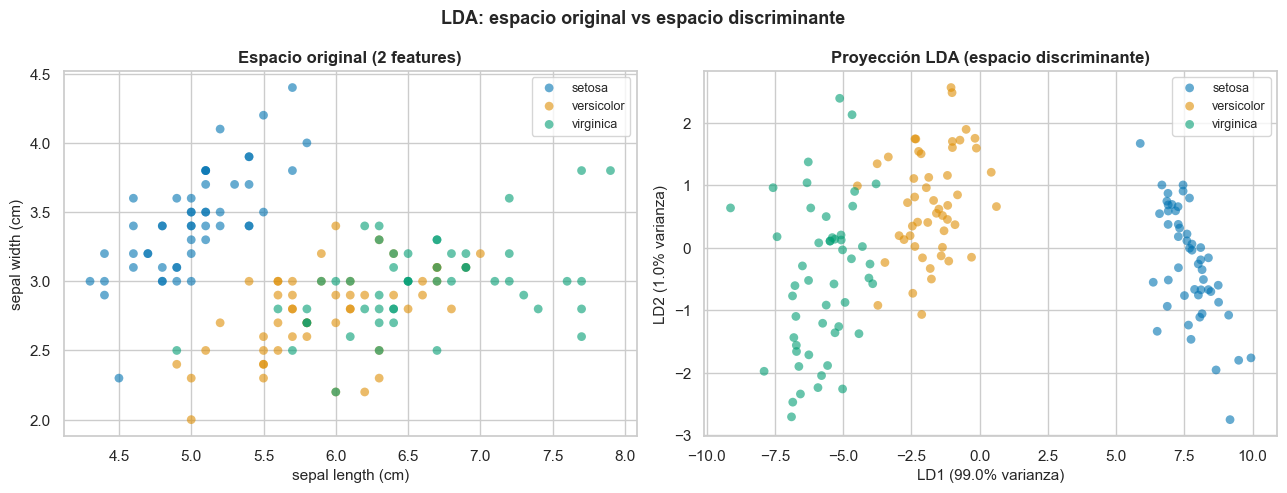

Observación: LDA separa mucho mejor las clases en su espacio discriminante.


In [9]:
# ━━━ SECCIÓN 3: LDA ━━━

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)
y_pred_lda = lda.predict(X_te)

print('=== LDA — Resultados ===')
print(f'Accuracy en test: {accuracy_score(y_te, y_pred_lda):.3f}')
print(f'\nVarianza explicada por cada eje discriminante: {lda.explained_variance_ratio_.round(3)}')
print('(LDA reduce a K-1 = 2 dimensiones para 3 clases)')

# Proyección en el espacio discriminante (reducción de dimensionalidad)
X_lda_proj = lda.transform(X_iris.values)  # proyectar todos los datos

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Espacio original (2 features)
colors = ['C0', 'C1', 'C2']
for k, (clase, col) in enumerate(zip(iris.target_names, colors)):
    mask = y_iris == k
    axes[0].scatter(X_iris.iloc[mask, 0], X_iris.iloc[mask, 1],
                    c=col, label=clase, alpha=0.6, edgecolors='none', s=40)
axes[0].set_xlabel(iris.feature_names[0], fontsize=11)
axes[0].set_ylabel(iris.feature_names[1], fontsize=11)
axes[0].set_title('Espacio original (2 features)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Espacio discriminante LDA (2 ejes)
for k, (clase, col) in enumerate(zip(iris.target_names, colors)):
    mask = y_iris == k
    axes[1].scatter(X_lda_proj[mask, 0], X_lda_proj[mask, 1],
                    c=col, label=clase, alpha=0.6, edgecolors='none', s=40)
axes[1].set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
axes[1].set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
axes[1].set_title('Proyección LDA (espacio discriminante)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('LDA: espacio original vs espacio discriminante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: LDA separa mucho mejor las clases en su espacio discriminante.')

> 💡 **Punto clave:** LDA hace dos cosas a la vez: clasifica **y** reduce la dimensionalidad. Para $K$ clases proyecta los datos en un espacio de $K-1$ dimensiones que maximiza la separación entre clases. Esto lo hace valioso incluso cuando no se usa como clasificador final.

---
## Sección 4 — QDA: Análisis de Discriminante Cuadrático

QDA es la versión más general: asume distribución gaussiana por clase con **covarianza propia de cada clase** $\Sigma_k$:

$$P(X = x \mid Y = k) = \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

Ahora el término cuadrático $(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)$ **no cancela** en la comparación entre clases, porque cada $\Sigma_k$ es distinta. La frontera resultante es una **cónica** (elipse, parábola, hipérbola o sus degeneraciones).

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>

**Cuándo QDA supera a LDA:** Cuando las clases tienen formas (covarianzas) muy distintas. Si una clase es muy alargada en una dirección y otra es circular, la frontera recta de LDA no se ajusta bien. QDA puede dibujar una curva que siga mejor esa asimetría.

**El precio:** QDA necesita estimar $K$ matrices de covarianza completas. Para $d$ features, cada matriz tiene $d(d+1)/2$ parámetros únicos. Con pocas muestras y muchas features, esto puede causar sobreajuste.

> 🤔 **Pregunta:** Para $d=100$ features y $K=3$ clases, ¿cuántos parámetros de covarianza necesita estimar QDA? ¿Y LDA?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la derivación? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>

**Función discriminante cuadrática:**
$$\delta_k(x) = -\frac{1}{2}\log|\Sigma_k| - \frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k) + \log\pi_k$$

El término $-\frac{1}{2}\log|\Sigma_k|$ penaliza clases con covarianza grande (alta entropía diferencial). La frontera entre $k$ y $l$ es una **superficie cuádrica**.

**Tabla unificada de supuestos:**

| Modelo | Covarianza | Parámetros de $\Sigma$ | Frontera |
|--------|-----------|----------------------|----------|
| GNB | $\text{diag}(\sigma_{kj}^2)$ — diagonal, por clase | $K \cdot d$ | Cuadrática (ejes alineados) |
| LDA | $\Sigma$ — completa, compartida | $d(d+1)/2$ | Lineal |
| QDA | $\Sigma_k$ — completa, por clase | $K \cdot d(d+1)/2$ | Cuadrática (libre) |

**Regularización:** `sklearn` implementa `LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')` que usa el estimador de Ledoit-Wolf para $\Sigma$ — útil cuando $n < d$.

> 📄 **Ref:** Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning*. Springer. Cap. 4.3. doi:10.1007/978-0-387-84858-7

> 🔬 **Para investigar:** ¿En qué régimen de $n/d$ falla la estimación de $\Sigma_k$ en QDA, y qué estimadores regularizados existen? Investiga RDA (Regularized Discriminant Analysis) de Friedman (1989).

<br>
<span style="font-size:0.85em; color:#7D6608;">→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.</span>
</div>

In [10]:
# ━━━ SECCIÓN 4: QDA ━━━

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_tr, y_tr)
y_pred_qda = qda.predict(X_te)

print('=== QDA — Resultados ===')
print(f'Accuracy en test: {accuracy_score(y_te, y_pred_qda):.3f}')
print()

# Contar parámetros de covarianza
d = X_iris.shape[1]
K = len(iris.target_names)
params_gnb = K * d * 2   # media + varianza por feature y clase
params_lda = d * (d + 1) // 2 + K * d   # Sigma compartida + K medias
params_qda = K * d * (d + 1) // 2 + K * d   # K Sigmas + K medias

print(f'Comparación de parámetros (d={d}, K={K}):')
print(f'  GNB : {params_gnb} parámetros')
print(f'  LDA : {params_lda} parámetros')
print(f'  QDA : {params_qda} parámetros')

=== QDA — Resultados ===
Accuracy en test: 1.000

Comparación de parámetros (d=4, K=3):
  GNB : 24 parámetros
  LDA : 22 parámetros
  QDA : 42 parámetros


---
## Sección 5 — Experimento Comparativo: Fronteras de Decisión

Comparamos los tres modelos visualmente sobre las 2 primeras features de Iris, y cuantitativamente con validación cruzada sobre el dataset completo.

/var/folders/hq/j1mtxtzj67j363wbx6731f6r0000gn/T/ipykernel_81887/2815293833.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORES_MAPA = plt.cm.get_cmap('tab10')


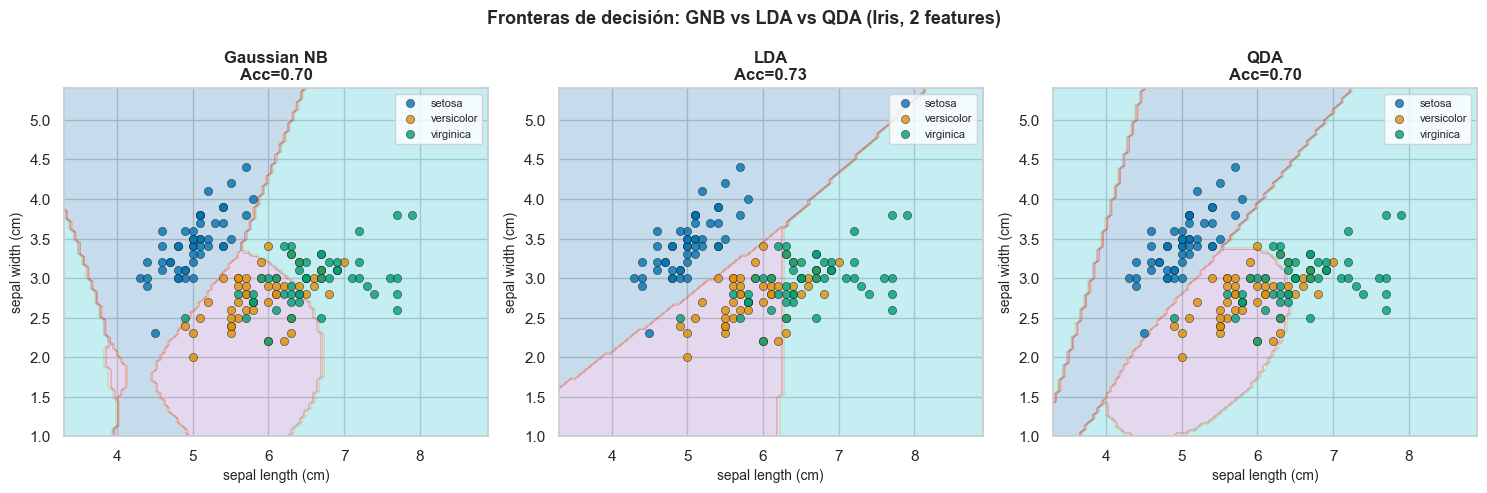

In [11]:
# ━━━ SECCIÓN 5: FRONTERAS DE DECISIÓN ━━━

# Usar solo 2 features para poder graficar en 2D
X_viz_tr, X_viz_te, y_viz_tr, y_viz_te = train_test_split(
    X_viz, y_iris.values, test_size=0.2, random_state=RANDOM_STATE, stratify=y_iris
)

modelos_viz = {
    'Gaussian NB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORES_MAPA = plt.cm.get_cmap('tab10')

for ax, (nombre, modelo) in zip(axes, modelos_viz.items()):
    modelo.fit(X_viz_tr, y_viz_tr)
    acc_viz = accuracy_score(y_viz_te, modelo.predict(X_viz_te))

    # Graficar frontera de decisión
    disp = DecisionBoundaryDisplay.from_estimator(
        modelo, X_viz,
        response_method='predict',
        alpha=0.25, ax=ax, cmap='tab10'
    )

    # Graficar puntos
    for k, (clase, col) in enumerate(zip(iris.target_names, ['C0','C1','C2'])):
        mask = y_iris == k
        ax.scatter(X_viz[mask, 0], X_viz[mask, 1],
                   label=clase, edgecolors='k', linewidths=0.4,
                   s=35, alpha=0.8, c=col)

    ax.set_xlabel(FEAT_VIZ[0], fontsize=10)
    ax.set_ylabel(FEAT_VIZ[1], fontsize=10)
    ax.set_title(f'{nombre}\nAcc={acc_viz:.2f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Fronteras de decisión: GNB vs LDA vs QDA (Iris, 2 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ━━━ COMPARACIÓN CON VALIDACIÓN CRUZADA (todas las features) ━━━

CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'f1_macro'

modelos_full = {
    'Gaussian NB' : GaussianNB(),
    'LDA'         : LinearDiscriminantAnalysis(),
    'QDA'         : QuadraticDiscriminantAnalysis()
}

print('=== Comparación 10-Fold CV — Iris (4 features) ===')
print(f'{"Modelo":15s} {"F1-macro":>10s}  {"±std":>8s}')
print('-' * 38)
for nombre, modelo in modelos_full.items():
    sc = cross_val_score(modelo, X_iris, y_iris, cv=CV, scoring=SCORING)
    print(f'{nombre:15s} {sc.mean():>10.3f}  {sc.std():>8.3f}')

print()
print('=== Comparación 10-Fold CV — Wine (13 features, más correlación) ===')
print(f'{"Modelo":15s} {"F1-macro":>10s}  {"±std":>8s}')
print('-' * 38)
for nombre, modelo in modelos_full.items():
    sc = cross_val_score(modelo, X_wine, y_wine, cv=CV, scoring=SCORING)
    print(f'{nombre:15s} {sc.mean():>10.3f}  {sc.std():>8.3f}')

=== Comparación 10-Fold CV — Iris (4 features) ===
Modelo            F1-macro      ±std
--------------------------------------
Gaussian NB          0.953     0.053
LDA                  0.973     0.044
QDA                  0.973     0.044

=== Comparación 10-Fold CV — Wine (13 features, más correlación) ===
Modelo            F1-macro      ±std
--------------------------------------
Gaussian NB          0.978     0.036
LDA                  0.989     0.023
QDA                  0.990     0.021


> 💡 **Punto clave:** En Iris (features relativamente independientes) los tres modelos se comportan de manera similar. En Wine (13 features con correlaciones fuertes) LDA y QDA suelen superar a NB porque pueden capturar esas relaciones. Esta diferencia ilustra directamente cuándo el supuesto de independencia de NB importa.

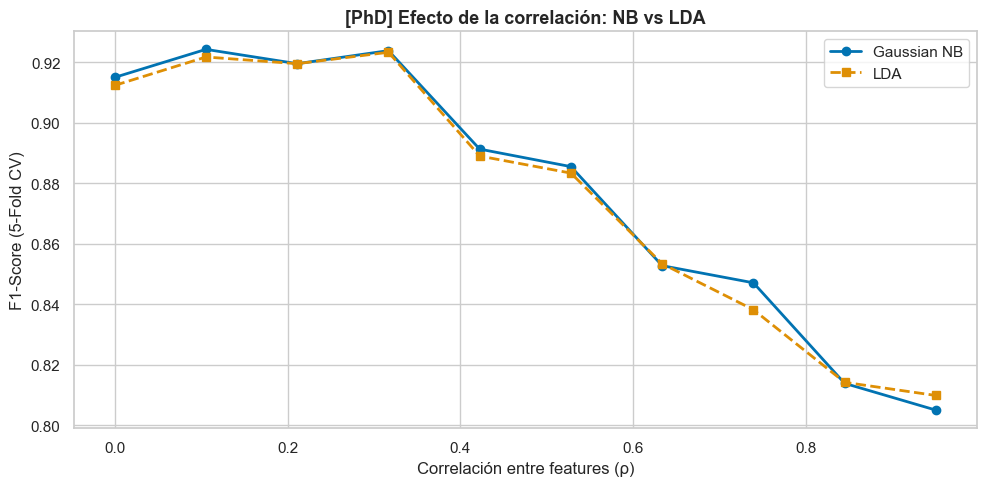

Observación: A medida que la correlación aumenta, LDA mantiene su desempeño
mientras NB puede degradarse cuando la correlación viola su supuesto de independencia.


In [13]:
# [PhD]
# ━━━ EXPERIMENTO: EFECTO DE LA CORRELACIÓN EN NB vs LDA ━━━
from sklearn.datasets import make_classification

# Generar datos con correlación creciente entre features
correlaciones = np.linspace(0, 0.95, 10)
scores_gnb_corr, scores_lda_corr = [], []

for rho in correlaciones:
    # Crear covarianza con correlación rho entre features 0 y 1
    cov = np.array([[1, rho], [rho, 1]])
    X_c = np.vstack([
        np.random.multivariate_normal([0, 0], cov, 200),
        np.random.multivariate_normal([2, 2], cov, 200)
    ])
    y_c = np.array([0]*200 + [1]*200)

    sc_gnb = cross_val_score(GaussianNB(), X_c, y_c, cv=5, scoring='f1').mean()
    sc_lda = cross_val_score(LinearDiscriminantAnalysis(), X_c, y_c, cv=5, scoring='f1').mean()
    scores_gnb_corr.append(sc_gnb)
    scores_lda_corr.append(sc_lda)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(correlaciones, scores_gnb_corr, 'o-', label='Gaussian NB', linewidth=2)
ax.plot(correlaciones, scores_lda_corr, 's--', label='LDA', linewidth=2)
ax.set_xlabel('Correlación entre features (ρ)', fontsize=12)
ax.set_ylabel('F1-Score (5-Fold CV)', fontsize=12)
ax.set_title('[PhD] Efecto de la correlación: NB vs LDA', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print('Observación: A medida que la correlación aumenta, LDA mantiene su desempeño')
print('mientras NB puede degradarse cuando la correlación viola su supuesto de independencia.')

---
## Sección 6 — Ejercicio en Clase

### Parte A — Sin computador (10 min) ✏️

Tienes un problema con **2 features** $(x_1, x_2)$ y **2 clases**. Los parámetros estimados son:

| Clase | $\mu_1$ | $\mu_2$ | $\sigma_1^2$ | $\sigma_2^2$ |
|-------|---------|---------|------------|------------|
| 0 | 2.0 | 1.0 | 1.0 | 1.0 |
| 1 | 5.0 | 4.0 | 1.0 | 1.0 |

Prior uniforme: $P(Y=0) = P(Y=1) = 0.5$.

**Responde en tu cuaderno:**
1. Usando Gaussian NB, clasifica el punto $x = (3.5, 2.5)$. Muestra el cálculo de log-verosimilitud.
2. ¿Qué modelo se reduciría a en este caso, NB o LDA? Justifica (pista: mira las varianzas).
3. ¿Dónde estaría la frontera de decisión de NB para este ejemplo?

In [14]:
# ── Verificación ejercicio A ── (ejecutar DESPUÉS de responder en el cuaderno)
import scipy.stats as ss

x_ej = np.array([3.5, 2.5])
params = {
    0: {'mu': [2.0, 1.0], 'var': [1.0, 1.0]},
    1: {'mu': [5.0, 4.0], 'var': [1.0, 1.0]}
}

print('=== Verificación Ejercicio A ===')
for k, p in params.items():
    log_like = sum(ss.norm.logpdf(x_ej[j], loc=p['mu'][j], scale=np.sqrt(p['var'][j]))
                   for j in range(2))
    log_post = np.log(0.5) + log_like
    print(f'Clase {k}: log-verosimilitud = {log_like:.3f} · log-posterior = {log_post:.3f}')

# Predicción
gnb_ej = GaussianNB()
X_ej = np.array([[2.0, 1.0], [2.0, 1.0], [5.0, 4.0], [5.0, 4.0]])
y_ej = np.array([0, 0, 1, 1])
gnb_ej.fit(X_ej, y_ej)
pred = gnb_ej.predict([x_ej])
prob = gnb_ej.predict_proba([x_ej])
print(f'\nClasificación de x=(3.5, 2.5): clase {pred[0]}')
print(f'Probabilidades: P(clase 0) = {prob[0,0]:.3f} · P(clase 1) = {prob[0,1]:.3f}')

=== Verificación Ejercicio A ===
Clase 0: log-verosimilitud = -4.088 · log-posterior = -4.781
Clase 1: log-verosimilitud = -4.088 · log-posterior = -4.781

Clasificación de x=(3.5, 2.5): clase 0
Probabilidades: P(clase 0) = 0.500 · P(clase 1) = 0.500


### Parte B — Ejercicio de código (15 min) 💻

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>

Usando el dataset **Wine** completo (13 features, 3 clases):
1. Compara GNB, LDA y QDA con Stratified 5-Fold CV (métrica: `f1_macro`).
2. Visualiza las fronteras de decisión usando los **2 primeros componentes LDA** como reducción de dimensionalidad.
3. ¿Cuál modelo recomendarías para este dataset? Justifica con los datos.

<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres la versión avanzada? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>

Además del punto anterior:
4. Estima la **matriz de covarianza** de cada clase en Wine. ¿Son iguales? Usa el test de Box's M (o una aproximación visual con `seaborn.heatmap`) para evaluar el supuesto de covarianzas iguales de LDA.
5. Compara LDA con `shrinkage='auto'` (Ledoit-Wolf) vs LDA sin regularización. ¿Cuál es más robusto en CV?
6. Verifica analíticamente para las clases 0 y 1 de Wine que la frontera de LDA es lineal calculando los coeficientes $w = \Sigma^{-1}(\mu_1 - \mu_0)$ y el intercepto.

<br>
<span style="font-size:0.85em; color:#7D6608;">→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.</span>
</div>

In [ ]:
# Espacio de trabajo para el ejercicio en clase
# Tu código aquí:


---
## Resumen Final

| Modelo | Supuesto de covarianza | Frontera | Parámetros | Cuándo usarlo |
|--------|----------------------|----------|-----------|---------------|
| Gaussian NB | Diagonal, por clase | Cuadrática (eje-alineada) | $2Kd$ | Features ≈ independientes, pocos datos |
| LDA | Completa, **compartida** | **Lineal** | $d(d+1)/2 + Kd$ | Clases con forma similar, también para reducción de dim. |
| QDA | Completa, **por clase** | **Cuadrática** | $Kd(d+1)/2 + Kd$ | Clases con formas distintas, suficientes datos |

**Hilo conductor:** Los tres son el mismo framework (Bayes + Gaussiana), pero con supuestos distintos sobre $\Sigma$. Más supuestos → menos parámetros → menos datos necesarios, pero más riesgo de sesgo si los supuestos se violan.

**Conexión con la próxima clase:** Estos modelos asumen que los datos dentro de cada clase son gaussianos. ¿Qué pasa cuando esa distribución es más compleja? La próxima clase introduce modelos de mezcla gaussiana (GMM) y la idea de distribuciones latentes.

---
## Bibliografía

### Pregrado
- Géron, A. (2022). *Hands-On Machine Learning* (3rd ed.). O'Reilly. Cap. 4.
- Müller & Guido (2016). *Introduction to Machine Learning with Python*. O'Reilly. Cap. 2.

### Doctorado / Investigación
- Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning*. Springer. Cap. 4.3. doi:10.1007/978-0-387-84858-7
- Murphy, K. P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press. Cap. 4.2.
- Ng & Jordan (2002). *On Discriminative vs. Generative Classifiers: A comparison of logistic regression and naive Bayes*. NIPS 2002.
- Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annals of Eugenics. doi:10.1111/j.1469-1809.1936.tb02137.x